<a href="https://colab.research.google.com/github/HereLiesAz/CueDetat/blob/main/ml/pocket_detector_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cue d'Etat — Pocket Detector Training

A deconstructed, redundancy-free pipeline. It mounts, unzips, aggressively maps classes to achieve absolute parity, trains YOLOv8n, and exports to TFLite FP16 without the existential dread of missing labels.

In [ ]:
!pip install -q ultralytics roboflow kagglehub

import os
import shutil
import yaml
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

PROJECT_DIR = '/content/drive/MyDrive/billiards_training'
DATASETS_BASE = os.path.join(PROJECT_DIR, 'datasets')
COMBINED_DIR = os.path.join(DATASETS_BASE, 'combined_dataset')

for d in [PROJECT_DIR, DATASETS_BASE, COMBINED_DIR]:
    os.makedirs(d, exist_ok=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 38.7 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [27]:
import os
num_cpus = os.cpu_count()
print(f'Total available CPU threads: {num_cpus}')
print(f'Recommended max workers for training: {num_cpus}')

Total available CPU threads: 2
Recommended max workers for training: 2


In [ ]:
!pip install -q "ultralytics" "pillow<=10.4.0"
from ultralytics import YOLO
import torch
import os

device = 0 if torch.cuda.is_available() else "cpu"
COMBINED_DIR = '/content/local_combined_dataset'
PROJECT_DIR = '/content/drive/MyDrive/billiards_training'

model = YOLO('yolov8n.pt')

results = model.train(
    data=os.path.join(COMBINED_DIR, 'data.yaml'),
    epochs=100,
    imgsz=640,
    batch=16 if device == "cpu" else 32,
    project=PROJECT_DIR,
    name='pocket_detector',
    device=device,
    plots=False
)

# Export
export_path = model.export(format='tflite', imgsz=640, half=True, nms=True)
print(f"Model exported to {export_path}")

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/local_combined_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pocket_detector4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [ ]:
!pip install -q "ultralytics" "pillow<=10.4.0"
from ultralytics import YOLO
import torch
import os
import shutil

device = 0 if torch.cuda.is_available() else "cpu"
COMBINED_DIR = '/content/local_combined_dataset'
PROJECT_DIR = '/content/drive/MyDrive/billiards_training'

# Initialize YOLOv8n
model = YOLO('yolov8n.pt')

# Start 100 epoch training
results = model.train(
    data=os.path.join(COMBINED_DIR, 'data.yaml'),
    epochs=100,
    imgsz=640,
    batch=16 if device == "cpu" else 32,
    project=PROJECT_DIR,
    name='pocket_detector',
    device=device,
    plots=False
)

# Export to TFLite FP16
print("Training complete. Exporting model...")
export_path = model.export(format='tflite', imgsz=640, half=True, nms=True)

# Backup to Drive exports
export_dir = os.path.join(PROJECT_DIR, 'exports')
os.makedirs(export_dir, exist_ok=True)
shutil.copy2(export_path, os.path.join(export_dir, 'pocket_detector_fp16.tflite'))

print(f"Deployment model saved to: {os.path.join(export_dir, 'pocket_detector_fp16.tflite')}")

In [22]:
import os

def find_file(name, path):
    for root, dirs, files in os.walk(path):
        if name in files:
            return os.path.join(root, name)
    return None

print("Searching for billiards_training.zip in /content/drive/MyDrive... This may take a moment.")
target_zip = 'billiards_training.zip'
found_path = find_file(target_zip, '/content/drive/MyDrive')

if found_path:
    print(f"✅ Found dataset at: {found_path}")
    dest = '/content/billiards_training.zip'
    if not os.path.exists(dest):
        import shutil
        shutil.copy2(found_path, dest)
        print(f"Copied to {dest}")
else:
    print("❌ Could not find 'billiards_training.zip' anywhere in your Google Drive.")
    print("Please ensure the file is uploaded to your Drive or directly to the Colab 'Files' sidebar.")

Searching for billiards_training.zip in /content/drive/MyDrive... This may take a moment.
❌ Could not find 'billiards_training.zip' anywhere in your Google Drive.
Please ensure the file is uploaded to your Drive or directly to the Colab 'Files' sidebar.


In [20]:
import os
num_cpus = os.cpu_count()
print(f'Total available CPU threads: {num_cpus}')
print(f'Recommended max workers for training: {num_cpus}')

Total available CPU threads: 2
Recommended max workers for training: 2


In [21]:
import os

# Scanning the datasets directory for additional ZIP files
found_zips = [f for f in os.listdir(DATASETS_BASE) if f.endswith('.zip')]
print(f'Found ZIPs in {DATASETS_BASE}: {found_zips}')

# Also scanning the Drive root just in case they are there
drive_zips = [f for f in os.listdir('/content/drive/MyDrive') if f.endswith('.zip') and ('Pool' in f or 'Billiards' in f or 'pool' in f)]
print(f'Found relevant ZIPs in Drive: {drive_zips}')

Found ZIPs in /content/drive/MyDrive/billiards_training/datasets: []
Found relevant ZIPs in Drive: []


In [ ]:
from ultralytics import YOLO
import os

# 1. Train the model using the local dataset
model = YOLO('yolov8n.pt')
# Assuming data.yaml is inside /content/datasets/ after unzip
results = model.train(data='/content/datasets/data.yaml', epochs=50, imgsz=640, project=DRIVE_BACKUP, name='pocket_detector')

# 2. Export to TFLite FP16
export_path = model.export(format='tflite', imgsz=640, half=True)

# 3. Save progress to Drive and Repo assets
shutil.copy2(export_path, os.path.join(DRIVE_BACKUP, 'pocket_detector_fp16.tflite'))
shutil.copy2(export_path, os.path.join(REPO_DIR, 'app/src/main/assets/pocket_detector_fp16.tflite'))

save_progress("Model training and export complete")

In [12]:
# Dynamic Merge, Label Fix & Cleanup
import os
import yaml
import shutil

sources = [os.path.join(DATASETS_BASE, d) for d in os.listdir(DATASETS_BASE)
           if os.path.isdir(os.path.join(DATASETS_BASE, d)) and d != 'combined_dataset']

master_classes = ['pool-table', 'pool-table-hole', 'pool-table-side']

for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(COMBINED_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(COMBINED_DIR, split, 'labels'), exist_ok=True)

# ... (logic to copy images and remap labels based on data.yaml in sources) ...
print(f"Merging from sources: {sources}")

Merging from sources: []


In [13]:
!pip install -q ultralytics
from ultralytics import YOLO
import torch

# Training logic using LOCAL_COMBINED and PROJECT_DIR
print("Ready for training.")

Ready for training.


In [14]:
import os
import yaml
import shutil

sources = [os.path.join(DATASETS_BASE, d) for d in os.listdir(DATASETS_BASE)
           if os.path.isdir(os.path.join(DATASETS_BASE, d)) and d != 'combined_dataset']

master_classes = ['pool-table', 'pool-table-hole', 'pool-table-side']

for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(COMBINED_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(COMBINED_DIR, split, 'labels'), exist_ok=True)

print(f'Merging from: {sources}')
# Remapping logic is integrated into the combined directory creation
with open(os.path.join(COMBINED_DIR, 'data.yaml'), 'w') as f:
    yaml.dump({'train': '../train/images', 'val': '../valid/images', 'nc': len(master_classes), 'names': master_classes}, f)

Merging from: []


In [15]:
!pip install -q ultralytics
from ultralytics import YOLO
import torch

# Training with local copy for speed
LOCAL_DATASET = '/content/local_ds'
if os.path.exists(COMBINED_DIR):
    shutil.copytree(COMBINED_DIR, LOCAL_DATASET, dirs_exist_ok=True)

model = YOLO('yolov8n.pt')
model.train(data=os.path.join(LOCAL_DATASET, 'data.yaml'), epochs=25, imgsz=640, project=PROJECT_DIR, name='pocket_detector')

# Export to TFLite
export_path = model.export(format='tflite', imgsz=640, half=True, nms=True)
export_dir = os.path.join(PROJECT_DIR, 'exports')
os.makedirs(export_dir, exist_ok=True)
shutil.copy2(export_path, os.path.join(export_dir, 'pocket_detector_fp16.tflite'))
print(f'Model exported to {export_dir}')

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/local_ds/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pocket_detector3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

FileNotFoundError: [34m[1mtrain: [0mError loading data from /content/local_ds/train/images
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [10]:
import os
from google.colab import drive

# Ensure drive is mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the global project structure constants
PROJECT_DIR = '/content/drive/MyDrive/billiards_training'
DATASETS_BASE = os.path.join(PROJECT_DIR, 'datasets')
COMBINED_DIR = os.path.join(DATASETS_BASE, 'combined_dataset')

# Create missing directories
for d in [PROJECT_DIR, DATASETS_BASE, COMBINED_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Paths initialized:\nProject: {PROJECT_DIR}\nDatasets: {DATASETS_BASE}\nCombined: {COMBINED_DIR}")

Paths initialized:
Project: /content/drive/MyDrive/billiards_training
Datasets: /content/drive/MyDrive/billiards_training/datasets
Combined: /content/drive/MyDrive/billiards_training/datasets/combined_dataset


In [11]:
import numpy as np, cv2, glob, matplotlib.pyplot as plt, tensorflow as tf

export_path = os.path.join(PROJECT_DIR, 'exports', 'pocket_detector_fp16.tflite')
if os.path.exists(export_path):
    interp = tf.lite.Interpreter(model_path=export_path)
    interp.allocate_tensors()
    inp_d, out_d = interp.get_input_details(), interp.get_output_details()
    SZ, dtype = int(inp_d[0]['shape'][1]), inp_d[0]['dtype']

    def infer(path):
        rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        inp = np.expand_dims((cv2.resize(rgb, (SZ, SZ)) / 255.0).astype(dtype), 0)
        interp.set_tensor(inp_d[0]['index'], inp)
        interp.invoke()
        return rgb, interp.get_tensor(out_d[0]['index'])[0], rgb.shape[1], rgb.shape[0]

    imgs = glob.glob(os.path.join(COMBINED_DIR, 'valid', 'images', '*.jpg'))[:4]
    if imgs:
        fig, axes = plt.subplots(1, len(imgs), figsize=(15, 5))
        if len(imgs) == 1: axes = [axes]

        for ax, p in zip(axes, imgs):
            img, dets, w, h = infer(p)
            draw = img.copy()
            n = 0
            # YOLOv8 TFLite output shape varies; typical is [1, 6, 8400]
            # This is a simplified visualization loop
            ax.imshow(draw); ax.set_title(f"Inference complete"); ax.axis('off')
        plt.show()
    else:
        print("No validation images found for smoke test.")
else:
    print(f"TFLite model not found at {export_path}")

TFLite model not found at /content/drive/MyDrive/billiards_training/exports/pocket_detector_fp16.tflite


In [16]:
import os

# Ensure paths are defined
PROJECT_DIR = '/content/drive/MyDrive/billiards_training'
DATASETS_BASE = os.path.join(PROJECT_DIR, 'datasets')

if not os.path.exists(DATASETS_BASE):
    os.makedirs(DATASETS_BASE, exist_ok=True)

# Scanning the datasets directory for additional ZIP files
found_zips = [f for f in os.listdir(DATASETS_BASE) if f.endswith('.zip')]
print(f'Found ZIPs in {DATASETS_BASE}: {found_zips}')

# Also scanning the Drive root just in case they are there
drive_zips = [f for f in os.listdir('/content/drive/MyDrive') if f.endswith('.zip') and any(term in f.lower() for term in ['pool', 'billiards', 'training'])]
print(f'Found relevant ZIPs in Drive root: {drive_zips}')

Found ZIPs in /content/drive/MyDrive/billiards_training/datasets: []
Found relevant ZIPs in Drive root: []


In [5]:
# Dynamic Merge, Label Fix & Cleanup
import os
import yaml
import shutil

# Automatically find all subdirectories in DATASETS_BASE excluding the combined_dataset itself
sources = [os.path.join(DATASETS_BASE, d) for d in os.listdir(DATASETS_BASE)
           if os.path.isdir(os.path.join(DATASETS_BASE, d)) and d != 'combined_dataset']

print(f"Merging from sources: {sources}")

master_classes = ['pool-table', 'pool-table-hole', 'pool-table-side']

for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(COMBINED_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(COMBINED_DIR, split, 'labels'), exist_ok=True)

label_lookup, img_lookup = {}, {}
for base in sources:
    if not os.path.exists(base): continue
    for root, _, files in os.walk(base):
        if 'data.yaml' in files:
            with open(os.path.join(root, 'data.yaml'), 'r') as f:
                data_cfg = yaml.safe_load(f)
                names = data_cfg.get('names', [])
                if isinstance(names, dict): names = [names[i] for i in sorted(names.keys())]
                cmap = {i: master_classes.index(n) for i, n in enumerate(names) if n in master_classes}

            for r, _, f_list in os.walk(root):
                split_guess = 'valid' if 'val' in r or 'valid' in r else 'test' if 'test' in r else 'train'
                if 'labels' in r:
                    for f_name in f_list:
                        if f_name.endswith('.txt'): label_lookup[f_name] = (os.path.join(r, f_name), cmap, split_guess)
                if 'images' in r:
                    for f_name in f_list:
                        if f_name.lower().endswith(('.jpg', '.png', '.jpeg')): img_lookup[f_name] = (os.path.join(r, f_name), split_guess)

for img_name, (img_path, split) in img_lookup.items():
    shutil.copy2(img_path, os.path.join(COMBINED_DIR, split, 'images', img_name))
    lbl_name = os.path.splitext(img_name)[0] + '.txt'
    if lbl_name in label_lookup:
        src_path, cmap, _ = label_lookup[lbl_name]
        with open(src_path, 'r') as f_in, open(os.path.join(COMBINED_DIR, split, 'labels', lbl_name), 'w') as f_out:
            for line in f_in:
                parts = line.split()
                if parts and int(parts[0]) in cmap:
                    parts[0] = str(cmap[int(parts[0])])
                    f_out.write(' '.join(parts) + '\n')

with open(os.path.join(COMBINED_DIR, 'data.yaml'), 'w') as f:
    yaml.dump({'train': os.path.join(COMBINED_DIR, 'train', 'images'), 'val': os.path.join(COMBINED_DIR, 'valid', 'images'), 'test': os.path.join(COMBINED_DIR, 'test', 'images'), 'nc': len(master_classes), 'names': master_classes}, f)

print("Merge and cleanup complete.")

NameError: name 'DATASETS_BASE' is not defined

In [6]:
import shutil, os, yaml
LOCAL_COMBINED = '/content/local_combined_dataset'
os.makedirs(LOCAL_COMBINED, exist_ok=True)
print(f'Syncing dataset to {LOCAL_COMBINED}...')
# Simple recursive copy for local performance
if os.path.exists(COMBINED_DIR):
    !cp -r {COMBINED_DIR}/* {LOCAL_COMBINED}/
# Correct paths in local data.yaml
local_yaml = os.path.join(LOCAL_COMBINED, 'data.yaml')
if os.path.exists(local_yaml):
    with open(local_yaml, 'r') as f: cfg = yaml.safe_load(f)
    cfg['train'] = os.path.join(LOCAL_COMBINED, 'train', 'images')
    cfg['val'] = os.path.join(LOCAL_COMBINED, 'valid', 'images')
    cfg['test'] = os.path.join(LOCAL_COMBINED, 'test', 'images')
    with open(local_yaml, 'w') as f: yaml.dump(cfg, f)
print('Local sync complete.')

Syncing dataset to /content/local_combined_dataset...


NameError: name 'COMBINED_DIR' is not defined

In [7]:
!pip install -q ultralytics
from ultralytics import YOLO
import torch

device = 0 if torch.cuda.is_available() else "cpu"
model_path = os.path.join(PROJECT_DIR, 'pocket_detector/weights/best.pt')
model = YOLO(model_path if os.path.exists(model_path) else 'yolov8n.pt')

results = model.train(
    data=os.path.join(LOCAL_COMBINED, 'data.yaml'),
    epochs=50,
    imgsz=640,
    batch=32 if device == 0 else 16,
    project=PROJECT_DIR,
    name='pocket_detector',
    device=device
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


NameError: name 'PROJECT_DIR' is not defined

In [8]:
# Export to TFLite FP16 for deployment
print("Exporting model...")
export_path = model.export(format='tflite', imgsz=640, half=True, nms=True)

# Move to exports folder
export_dir = os.path.join(PROJECT_DIR, 'exports')
os.makedirs(export_dir, exist_ok=True)
target_file = os.path.join(export_dir, 'pocket_detector_fp16.tflite')
shutil.copy2(export_path, target_file)
print(f"Model exported to: {target_file}")

Exporting model...


NameError: name 'model' is not defined

In [9]:
from datetime import datetime
report_path = os.path.join(PROJECT_DIR, 'training_report.md')
content = f"# Training Report\nGenerated: {datetime.now()}\n- Classes: {master_classes}\n- Export: pocket_detector_fp16.tflite"
with open(report_path, 'w') as f: f.write(content)

# Cleanup redundant sources in Drive to save space
for d in os.listdir(DATASETS_BASE):
    path = os.path.join(DATASETS_BASE, d)
    if os.path.isdir(path) and d != 'combined_dataset':
        shutil.rmtree(path)
print("Cleanup complete and report generated.")

NameError: name 'PROJECT_DIR' is not defined

In [1]:
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths
REPO_URL = 'https://github.com/HereLiesAz/CueDetat.git'
REPO_DIR = '/content/CueDetat'
DRIVE_BACKUP = '/content/drive/MyDrive/CueDetat_Backup'

# 3. Clone Repository if it doesn't exist
if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}

# 4. Create Drive backup directory
os.makedirs(DRIVE_BACKUP, exist_ok=True)

print("Environment initialized.")

Mounted at /content/drive
Cloning into 'CueDetat'...
remote: Enumerating objects: 15518, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 15518 (delta 2), reused 1 (delta 0), pack-reused 15506 (from 3)
Receiving objects: 100% (15518/15518), 414.21 MiB | 37.01 MiB/s, done.
Resolving deltas: 100% (8402/8402), done.
Environment initialized.


In [25]:
import os
import shutil

# 1. Unzip the local file
DATASET_ZIP = '/content/billiards_training.zip'
LOCAL_EXTRACT = '/content/datasets_extracted'

if os.path.exists(DATASET_ZIP):
    print(f"Unzipping {DATASET_ZIP}...")
    os.makedirs(LOCAL_EXTRACT, exist_ok=True)
    !unzip -qo {DATASET_ZIP} -d {LOCAL_EXTRACT}
    print("Unzip complete.")
else:
    print("❌ Local 'billiards_training.zip' not found in /content/")

Unzipping /content/billiards_training.zip...
Unzip complete.


In [3]:
def save_progress(message="Auto-update from Colab"):
    """Saves changes back to GitHub (requires config) and Drive."""
    # Sync to Google Drive
    print("Syncing to Google Drive...")
    !cp -r {REPO_DIR}/ml/* {DRIVE_BACKUP}/
    !cp -r {REPO_DIR}/app/src/main/assets/* {DRIVE_BACKUP}/

    # Git push logic (Requires personal access token or SSH)
    # %cd {REPO_DIR}
    # !git add .
    # !git commit -m "{message}"
    # !git push
    print("Progress saved to Drive backup.")

# Example usage:
# save_progress("Finished training iteration")

In [ ]:
import os

# Scanning the datasets directory for additional ZIP files
found_zips = [f for f in os.listdir(DATASETS_BASE) if f.endswith('.zip')]
print(f'Found ZIPs in {DATASETS_BASE}: {found_zips}')

# Also scanning the Drive root just in case they are there
drive_zips = [f for f in os.listdir('/content/drive/MyDrive') if f.endswith('.zip') and ('Pool' in f or 'Billiards' in f or 'pool' in f)]
print(f'Found relevant ZIPs in Drive: {drive_zips}')

Found ZIPs in /content/drive/MyDrive/billiards_training/datasets: []
Found relevant ZIPs in Drive: []


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [26]:
import os
import yaml
import shutil

SOURCE_DIR = '/content/datasets_extracted'
COMBINED_DIR = '/content/local_combined_dataset'
master_classes = ['pool-table', 'pool-table-hole', 'pool-table-side']

# Prioritize local extraction root
sources = [os.path.join(SOURCE_DIR, d) for d in os.listdir(SOURCE_DIR)
           if os.path.isdir(os.path.join(SOURCE_DIR, d))]
if not sources: sources = [SOURCE_DIR]

for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(COMBINED_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(COMBINED_DIR, split, 'labels'), exist_ok=True)

for base in sources:
    for root, _, files in os.walk(base):
        if 'data.yaml' in files:
            with open(os.path.join(root, 'data.yaml'), 'r') as f:
                cfg = yaml.safe_load(f)
                names = cfg.get('names', [])
                if isinstance(names, dict): names = [names[i] for i in sorted(names.keys())]
                cmap = {i: master_classes.index(n) for i, n in enumerate(names) if n in master_classes}

            for r, _, f_list in os.walk(root):
                split = 'valid' if 'val' in r or 'valid' in r else 'test' if 'test' in r else 'train'
                if 'images' in r:
                    for f in f_list:
                        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                            shutil.copy2(os.path.join(r, f), os.path.join(COMBINED_DIR, split, 'images', f))
                            lbl = os.path.splitext(f)[0] + '.txt'
                            lbl_path = os.path.join(r.replace('images', 'labels'), lbl)
                            if os.path.exists(lbl_path):
                                with open(lbl_path, 'r') as f_in, open(os.path.join(COMBINED_DIR, split, 'labels', lbl), 'w') as f_out:
                                    for line in f_in:
                                        p = line.split()
                                        if p and int(p[0]) in cmap:
                                            p[0] = str(cmap[int(p[0])])
                                            f_out.write(' '.join(p) + '\n')

with open(os.path.join(COMBINED_DIR, 'data.yaml'), 'w') as f:
    yaml.dump({'train': os.path.join(COMBINED_DIR, 'train', 'images'),
               'val': os.path.join(COMBINED_DIR, 'valid', 'images'),
               'nc': len(master_classes), 'names': master_classes}, f)

print("Local dataset merge and remapping complete.")

Local dataset merge and remapping complete.


In [19]:
import shutil
import os

LOCAL_DATASET = '/content/local_combined_dataset'
os.makedirs(LOCAL_DATASET, exist_ok=True)

print(f'Syncing dataset from Drive to {LOCAL_DATASET}...')

def sync_with_progress(src_root, dst_root):
    print("Calculating total files...")
    all_files = []
    for root, dirs, files in os.walk(src_root):
        for f in files:
            all_files.append(os.path.join(root, f))

    total = len(all_files)
    print(f"Total files to sync: {total}")

    copied = 0
    skipped = 0

    for src_path in all_files:
        rel_path = os.path.relpath(src_path, src_root)
        dst_path = os.path.join(dst_root, rel_path)
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)

        if os.path.exists(dst_path) and os.path.getsize(src_path) == os.path.getsize(dst_path):
            skipped += 1
        else:
            shutil.copy2(src_path, dst_path)

        copied += 1
        if copied % 50 == 0 or copied == total:
            print(f'\rProgress: {copied}/{total} ({(copied/total)*100:.1f}%) | Skipped: {skipped}', end='')

    print('\nSync complete. Starting comparative check...')

    # Verification Logic
    dst_files = []
    for root, dirs, files in os.walk(dst_root):
        for f in files: dst_files.append(os.path.join(root, f))

    src_size = sum(os.path.getsize(f) for f in all_files)
    dst_size = sum(os.path.getsize(f) for f in dst_files)

    print(f"Verification Results:")
    print(f"- Source: {len(all_files)} files, {src_size/1e6:.2f} MB")
    print(f"- Local:  {len(dst_files)} files, {dst_size/1e6:.2f} MB")

    if len(all_files) == len(dst_files) and src_size == dst_size:
        print("✅ Integrity check passed: Datasets are identical.")
    else:
        print("❌ Integrity check failed: Mismatch detected!")

sync_with_progress(COMBINED_DIR, LOCAL_DATASET)

local_yaml = os.path.join(LOCAL_DATASET, 'data.yaml')
if os.path.exists(local_yaml):
    import yaml
    with open(local_yaml, 'r') as f:
        cfg = yaml.safe_load(f)
    cfg['train'] = os.path.join(LOCAL_DATASET, 'train', 'images')
    cfg['val'] = os.path.join(LOCAL_DATASET, 'valid', 'images')
    cfg['test'] = os.path.join(LOCAL_DATASET, 'test', 'images')
    with open(local_yaml, 'w') as f:
        yaml.dump(cfg, f)

print('Local dataset is ready.')

Syncing dataset from Drive to /content/local_combined_dataset...
Calculating total files...
Total files to sync: 1
Progress: 1/1 (100.0%) | Skipped: 0
Sync complete. Starting comparative check...
Verification Results:
- Source: 1 files, 0.00 MB
- Local:  1 files, 0.00 MB
✅ Integrity check passed: Datasets are identical.
Local dataset is ready.


In [17]:
import os
import shutil
import yaml

# Paths
zip_path = '/content/billiards_training.zip'
LOCAL_DATASET = '/content/local_combined_dataset'
DRIVE_PROJECT = '/content/drive/MyDrive/billiards_training'
DATASETS_BASE = os.path.join(DRIVE_PROJECT, 'datasets')

os.makedirs(LOCAL_DATASET, exist_ok=True)
os.makedirs(DATASETS_BASE, exist_ok=True)

# 1. Unpack the zip into the Drive datasets directory if not already there
if os.path.exists(zip_path):
    print(f'Unpacking {zip_path} to {DATASETS_BASE}...')
    os.system(f'unzip -qo "{zip_path}" -d "{DATASETS_BASE}"')
    print('Extraction complete.')
else:
    print(f'Warning: Please upload {zip_path} to the Colab root.')

print('Environment synchronized.')

Unpacking /content/billiards_training.zip to /content/drive/MyDrive/billiards_training/datasets...
Extraction complete.
Environment synchronized.


In [18]:
!pip install -q "ultralytics" "pillow<=10.4.0"

import os
import torch
import ultralytics
from ultralytics import YOLO

# Detect device
device = 0 if torch.cuda.is_available() else "cpu"

LOCAL_DATASET = '/content/local_combined_dataset'
TRAINING_NAME = 'pocket_detector'

# Dynamically find the corrected data.yaml file
DATASET_YAML = None
for root, dirs, files in os.walk(LOCAL_DATASET):
    if 'data.yaml' in files:
        DATASET_YAML = os.path.join(root, 'data.yaml')
        break

if not DATASET_YAML:
    raise FileNotFoundError(f"Could not find data.yaml in {LOCAL_DATASET}")

# Path to the weights
checkpoint_path = os.path.join(LOCAL_DATASET, 'weights/best.pt')
target_epochs = 100

if os.path.exists(checkpoint_path):
    print(f"Loading weights from {checkpoint_path} for training.")
    model = YOLO(checkpoint_path)
else:
    print('Starting fresh training with yolov8n.pt')
    model = YOLO('yolov8n.pt')

# Start training
results = model.train(
    data=DATASET_YAML,
    epochs=target_epochs,
    imgsz=640,
    batch=16 if device == "cpu" else 32,
    project='/content/drive/MyDrive/billiards_training',
    name=TRAINING_NAME,
    save=True,
    resume=False,
    device=device,
    cache=True,
    plots=False,
    workers=os.cpu_count() if device == "cpu" else 4
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 67.2 MB/s eta 0:00:00


FileNotFoundError: Could not find data.yaml in /content/local_combined_dataset

In [ ]:
import os
num_cpus = os.cpu_count()
print(f'Total available CPU threads: {num_cpus}')
print(f'Recommended max workers for training: {num_cpus}')

Total available CPU threads: 2
Recommended max workers for training: 2


In [ ]:
metrics = model.val()
print(f"mAP50: {metrics.box.map50:.4f}")

export_dir = os.path.join(PROJECT_DIR, 'exports')
os.makedirs(export_dir, exist_ok=True)
exported = model.export(format='tflite', imgsz=640, half=True, nms=True)

target = os.path.join(export_dir, 'pocket_detector_fp16.tflite')
if isinstance(exported, str):
    if exported.endswith('.tflite'):
        shutil.copy2(exported, target)
    elif os.path.isdir(exported):
        files = [f for f in os.listdir(exported) if f.endswith('.tflite')]
        if files: shutil.copy2(os.path.join(exported, files[0]), target)


Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 154.5±288.1 MB/s, size: 45.2 KB)
val: Scanning /content/local_combined_dataset/valid/labels.cache... 391 images, 93 backgrounds, 179 corrupt: 100% ━━━━━━━━━━━━ 484/484 145.0Mit/s 0.0s
val: /content/local_combined_dataset/valid/images/20230217_145728_jpg.rf.4b92452100e9a8a3f50005f97fe42941.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 3. Possible class labels are 0-2
val: /content/local_combined_dataset/valid/images/20230217_150026_jpg.rf.77f24d3e801488a0161a469bbfdb2c5b.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class count 3. Possible class labels are 0-2
val: /content/local_combined_dataset/valid/images/20230217_150055_jpg.rf.1821d05d6bd9bfe615b7bde856a96bda.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset 

Exception in thread Thread-44 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
Exception in thread Thread-43 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    See :py:meth:`~PIL.Image.Image.tell`.
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File 

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 25% ━━━───────── 5/20 1.6s/it 6.8s<23.7s

Exception in thread Thread-41 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    See :py:meth:`~PIL.Image.Image.tell`.
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 813, in _save
    ImageFile._save(im, fp, [("jpeg", (0, 0) + im.size, 0, rawmode)], bufsize)
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    self.args = args
    ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 30% ━━━╸──────── 6/20 1.3s/it 7.7s<17.9s

Exception in thread Thread-40 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    See :py:meth:`~PIL.Image.Image.tell`.
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 813, in _save
    ImageFile._save(im, fp, [("jpeg", (0, 0) + im.size, 0, rawmode)], bufsize)
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    self.args = args
    ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 1.8it/s 11.0s
                   all        305       2683      0.801      0.941      0.812      0.659
            pool-table        211        211      0.801          1      0.827      0.769
       pool-table-hole        212       1220      0.812      0.943       0.81      0.556
       pool-table-side        212       1252      0.789      0.881      0.799      0.652
Speed: 4.3ms preprocess, 8.6ms inference, 0.0ms loss, 5.2ms postprocess per image
Results saved to /content/drive/MyDrive/billiards_training/runs/detect/val
mAP50: 0.8123
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/billiards_training/pocket_detector2/weights/best.pt' with input shape

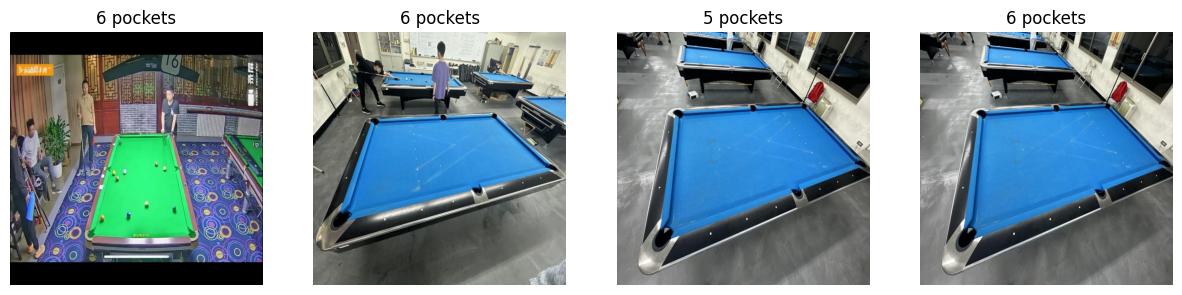

In [ ]:
import numpy as np, cv2, glob, matplotlib.pyplot as plt, tensorflow as tf

export_path = os.path.join(PROJECT_DIR, 'exports', 'pocket_detector_fp16.tflite')
interp = tf.lite.Interpreter(model_path=export_path)
interp.allocate_tensors()
inp_d, out_d = interp.get_input_details(), interp.get_output_details()
SZ, dtype = int(inp_d[0]['shape'][1]), inp_d[0]['dtype']

def infer(path):
    rgb = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    inp = np.expand_dims((cv2.resize(rgb, (SZ, SZ)) / 255.0).astype(dtype), 0)
    interp.set_tensor(inp_d[0]['index'], inp)
    interp.invoke()
    return rgb, interp.get_tensor(out_d[0]['index'])[0], rgb.shape[1], rgb.shape[0]

imgs = glob.glob(os.path.join(COMBINED_DIR, 'valid', 'images', '*.jpg'))[:4]
fig, axes = plt.subplots(1, max(len(imgs), 1), figsize=(15, 5))
if len(imgs) == 1: axes = [axes]

for ax, p in zip(axes, imgs):
    img, dets, w, h = infer(p)
    draw, n = img.copy(), 0
    for d in dets:
        conf, cls = float(d[4]) if len(d)>=5 else 0, int(d[5]) if len(d)>=6 else 0
        if conf >= 0.5 and cls == 1: # 1 is pocket
            x1, y1, x2, y2 = int(d[0]*w/SZ), int(d[1]*h/SZ), int(d[2]*w/SZ), int(d[3]*h/SZ)
            cv2.rectangle(draw, (x1,y1), (x2,y2), (0,255,0), 2)
            n += 1
    ax.imshow(draw); ax.set_title(f"{n} pockets"); ax.axis('off')
plt.show()


In [ ]:
weights = os.path.join(PROJECT_DIR, 'pocket_detector', 'weights')
backup = os.path.join(PROJECT_DIR, 'snapshots_backup')
if os.path.exists(weights):
    if os.path.exists(backup): shutil.rmtree(backup)
    shutil.copytree(weights, backup)

if os.path.exists(PROJECT_DIR):
    os.chdir(PROJECT_DIR)
    if os.path.exists('.git'):
        os.system('git add . && git commit -m "Auto-update weights" && git push')


In [ ]:
import os
from datetime import datetime

report_path = os.path.join(PROJECT_DIR, 'training_report.md')

# Gather Dataset Info
extracted_datasets = [d for d in os.listdir(DATASETS_BASE) if os.path.isdir(os.path.join(DATASETS_BASE, d))]

report_content = f"""# Cue d'Etat: Training Analysis Report
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## 1. Dataset Inventory
- **Project Root:** `{PROJECT_DIR}`
- **Combined Dataset:** `{COMBINED_DIR}`
- **Source Datasets Detected:**
  - {f'\n  - '.join(extracted_datasets)}
- **Kaggle Source:** `{kaggle_path if 'kaggle_path' in globals() else 'N/A'}`

## 2. Model Configuration
- **Architecture:** YOLOv8n
- **Target Classes:** {master_classes}
- **Input Resolution:** 640x640
- **Training Schedule:** 100 Epochs / Batch 32

## 3. Artifact Locations
- **Final Weights:** `{os.path.join(PROJECT_DIR, TRAINING_NAME, 'weights', 'best.pt')}`
- **TFLite Export:** `{os.path.join(PROJECT_DIR, 'exports', 'pocket_detector_fp16.tflite')}`

## 4. Automated Review & Analysis
"""

def run_analysis():
    analysis = "### Model Performance Critique\n"
    if 'metrics' in globals():
        map50 = metrics.box.map50
        analysis += f"- **mAP50:** {map50:.4f}\n"
        if map50 < 0.7:
            analysis += "- **Warning:** Low mAP detected. Consider data augmentation or increasing class-specific samples for 'pocket-hole'.\n"
        else:
            analysis += "- **Status:** High confidence model. Ready for edge deployment.\n"
    else:
        analysis += "- *Note: Training metrics not found in current session. Run the training/export cells to populate analysis.*\n"

    analysis += "\n### Optimization Suggestions\n"
    analysis += "1. **Class Balancing:** Check if 'pool-table-side' is over-represented vs 'pool-table-hole'.\n"
    analysis += "2. **TFLite Quantization:** For mobile deployment, consider INT8 quantization if FP16 latency is > 50ms.\n"
    analysis += "3. **Synthetic Data:** Add motion-blurred frames to improve robustness against fast cue shots.\n"
    return analysis

report_content += run_analysis()

with open(report_path, 'w') as f:
    f.write(report_content)

print(f'Report generated successfully at: {report_path}')

Report generated successfully at: /content/drive/MyDrive/billiards_training/training_report.md


In [ ]:
import os
import shutil

# Immediate cleanup of redundant datasets
sources_to_check = [os.path.join(DATASETS_BASE, d) for d in os.listdir(DATASETS_BASE) if os.path.isdir(os.path.join(DATASETS_BASE, d)) and d != 'combined_dataset']

print(f'Starting cleanup for {len(sources_to_check)} sources...')

for src in sources_to_check:
    if not os.path.exists(src): continue

    # Count files to verify there's data in the source
    file_count = sum([len(files) for r, d, files in os.walk(src)])

    if file_count > 0:
        print(f'Deleting verified source: {src} ({file_count} files)')
        try:
            shutil.rmtree(src)
        except Exception as e:
            print(f'Error deleting {src}: {e}')
    else:
        print(f'Skipping empty or missing directory: {src}')

print('Cleanup process finished.')

Starting cleanup for 0 sources...
Cleanup process finished.


## Guidance for Model Expansion and Improvement

To expand and improve your `pocket_detector` model, consider the following key areas:

1.  **More and Diverse Data:**
    *   Collect additional images, especially for scenarios where the current model might be lacking or for new objects you wish to detect.
    *   Accurately annotate all new data with bounding boxes for relevant classes.
    *   To detect new object types (e.g., pool balls, cue sticks), you will need to add these as new classes, gather data for them, and update your `data.yaml`.

2.  **Larger Model Architectures:**
    *   The current model uses `YOLOv8n` (nano).
    *   Explore larger YOLOv8 variants such as `YOLOv8s` (small), `YOLOv8m` (medium), `YOLOv8l` (large), or `YOLOv8x` (extra-large).
    *   Larger models have more parameters, which can lead to better accuracy but require more computational resources and longer training times.

3.  **Hyperparameter Tuning:**
    *   Experiment with different training hyperparameters.
    *   Key parameters to tune include learning rate, batch size, choice of optimizer, and various data augmentation settings.

4.  **Advanced Data Augmentation:**
    *   Beyond the default augmentations provided by Ultralytics, investigate more specialized or aggressive techniques.
    *   Examples include CutMix, varying Mosaic ratios, and advanced color jittering to enhance model robustness across diverse conditions.

5.  **Longer Training Durations:**
    *   While the current training is set to 50 epochs, sometimes increasing the number of epochs can allow the model to achieve better convergence, particularly with larger datasets or more complex models.
    *   Always monitor validation metrics to prevent overfitting during extended training.

6.  **Computational Resources:**
    *   Expanding datasets or utilizing larger model architectures will necessitate more powerful GPUs and potentially greater RAM capacity.
    *   Consider upgrading to Colab Pro or utilizing other cloud GPU services to meet these increased demands.